# YOLOv8 KITTI Training Notebook
**Folder structure expected:**
```
my_yolo_project/
├── model.py
├── train.ipynb          ← this file
├── data/
│   ├── images/train/
│   ├── images/val/
│   ├── labels/train/    ← YOLO format .txt files
│   └── labels/val/
├── weights/             ← best.pt saved here
└── runs/                ← tensorboard logs
```

## Cell 1 — Imports & Device Setup

pip install tensorboard

pip install torchvision Pillow matplotlib numpy

In [1]:
import os
import time
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.utils.tensorboard import SummaryWriter
import torchvision.transforms as T
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from pathlib import Path

from model import YOLOv8_KITTI

# ── Device ──────────────────────────────────────────────────
device = (
    'cuda'  if torch.cuda.is_available() else
    'mps'   if torch.backends.mps.is_available() else
    'cpu'
)
print(f'Using device: {device}')
if device == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

Using device: cuda
GPU: NVIDIA GeForce RTX 5060 Ti
VRAM: 17.1 GB


## Cell 2 — Config (edit these before training)

In [2]:
# ── Model ───────────────────────────────────────────────────
VERSION     = 's'       # 'n' | 's' | 'm' | 'l' | 'x'
NC          = 8         # KITTI classes
IMG_SIZE    = 640

# ── Training ────────────────────────────────────────────────
EPOCHS      = 100
BATCH_SIZE  = 8         # reduce to 4 if you get OOM errors
LR          = 1e-3
LR_MIN      = 1e-5      # cosine annealing floor
WEIGHT_DECAY= 5e-4
GRAD_CLIP   = 10.0      # max gradient norm

# ── Loss weights ────────────────────────────────────────────
W_BOX       = 7.5       # bbox regression weight
W_CLS       = 0.5       # classification weight

# ── Paths ───────────────────────────────────────────────────
DATA_ROOT   = Path('data')
WEIGHTS_DIR = Path('weights');  WEIGHTS_DIR.mkdir(exist_ok=True)
RUNS_DIR    = Path('runs');     RUNS_DIR.mkdir(exist_ok=True)

# ── KITTI class names ───────────────────────────────────────
CLASS_NAMES = [
    'Car', 'Van', 'Truck', 'Pedestrian',
    'Person_sitting', 'Cyclist', 'Tram', 'Misc'
]

print('Config ready.')
print(f'  Model version : {VERSION}')
print(f'  Epochs        : {EPOCHS}')
print(f'  Batch size    : {BATCH_SIZE}')
print(f'  Image size    : {IMG_SIZE}')

Config ready.
  Model version : s
  Epochs        : 100
  Batch size    : 8
  Image size    : 640


## Cell 3 — Dataset
Labels must be YOLO format: one `.txt` per image, each line = `class cx cy w h` (all normalised 0–1).

In [3]:
class KITTIDataset(Dataset):
    """
    Loads images + YOLO-format labels.
    Each label line: class_id  cx  cy  w  h  (normalised)
    """
    def __init__(self, img_dir, label_dir, img_size=640, augment=False):
        self.img_dir   = Path(img_dir)
        self.label_dir = Path(label_dir)
        self.img_size  = img_size
        self.augment   = augment

        self.img_files = sorted([
            f for f in self.img_dir.iterdir()
            if f.suffix.lower() in ('.jpg', '.jpeg', '.png')
        ])

        # Base transforms (always applied)
        self.base_tf = T.Compose([
            T.Resize((img_size, img_size)),
            T.ToTensor(),
            T.Normalize(mean=[0.485, 0.456, 0.406],
                        std =[0.229, 0.224, 0.225]),
        ])

        # Augmentation transforms (train only)
        self.aug_tf = T.Compose([
            T.ColorJitter(brightness=0.4, contrast=0.4,
                          saturation=0.4, hue=0.1),
            T.RandomHorizontalFlip(p=0.5),
        ])

        print(f'Dataset loaded: {len(self.img_files)} images from {img_dir}')

    def __len__(self):
        return len(self.img_files)

    def __getitem__(self, idx):
        img_path   = self.img_files[idx]
        label_path = self.label_dir / (img_path.stem + '.txt')

        # Load image
        img = Image.open(img_path).convert('RGB')
        if self.augment:
            img = self.aug_tf(img)
        img = self.base_tf(img)   # (3, H, W) tensor

        # Load labels
        labels = []
        if label_path.exists():
            with open(label_path) as f:
                for line in f:
                    vals = line.strip().split()
                    if len(vals) == 5:
                        labels.append([float(v) for v in vals])

        # labels shape: (N, 5) — [class, cx, cy, w, h]
        labels = torch.tensor(labels, dtype=torch.float32) if labels else torch.zeros((0, 5))
        return img, labels, str(img_path)


def collate_fn(batch):
    """Custom collate to handle variable number of boxes per image."""
    imgs, labels, paths = zip(*batch)
    imgs = torch.stack(imgs, 0)
    # Tag each label row with its batch index
    tagged = []
    for i, lab in enumerate(labels):
        if lab.shape[0] > 0:
            idx_col = torch.full((lab.shape[0], 1), i)
            tagged.append(torch.cat((idx_col, lab), 1))  # (N, 6): [batch_idx, cls, cx, cy, w, h]
    labels_out = torch.cat(tagged, 0) if tagged else torch.zeros((0, 6))
    return imgs, labels_out, paths


# Instantiate datasets
train_dataset = KITTIDataset(
    img_dir   = DATA_ROOT / 'images/train',
    label_dir = DATA_ROOT / 'labels/train',
    img_size  = IMG_SIZE,
    augment   = True
)
val_dataset = KITTIDataset(
    img_dir   = DATA_ROOT / 'images/val',
    label_dir = DATA_ROOT / 'labels/val',
    img_size  = IMG_SIZE,
    augment   = False
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          shuffle=True,  collate_fn=collate_fn,
                          num_workers=0, pin_memory=(device=='cuda'))
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE,
                          shuffle=False, collate_fn=collate_fn,
                          num_workers=0, pin_memory=(device=='cuda'))

print(f'Train batches : {len(train_loader)}')
print(f'Val   batches : {len(val_loader)}')

Dataset loaded: 5985 images from data\images\train
Dataset loaded: 1496 images from data\images\val
Train batches : 749
Val   batches : 187


## Cell 4 — Visualise a training batch (sanity check)

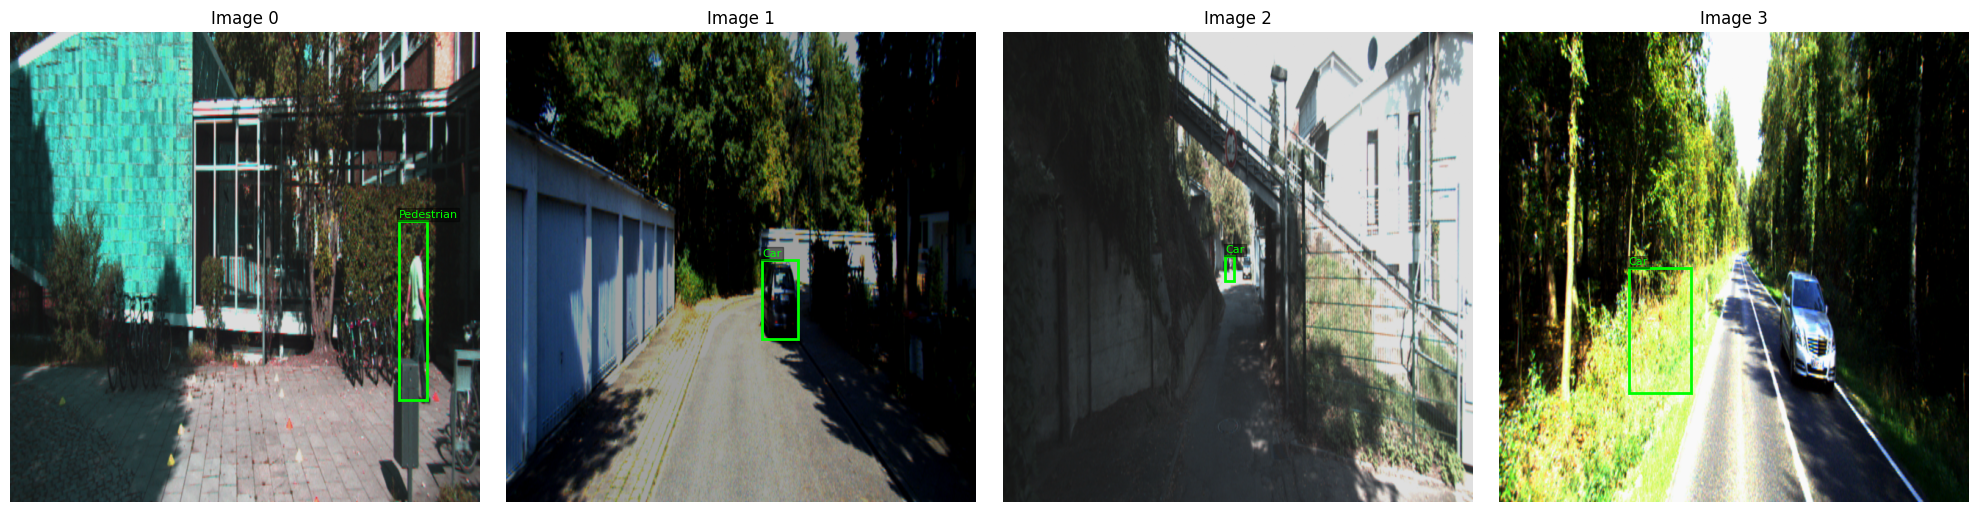

Label tensor shape: torch.Size([34, 6])  — columns: [batch_idx, cls, cx, cy, w, h]


In [4]:
def denorm(tensor):
    """Reverse ImageNet normalisation for display."""
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
    return (tensor * std + mean).clamp(0, 1)

imgs, labels, _ = next(iter(train_loader))
n_show = min(4, imgs.shape[0])

fig, axes = plt.subplots(1, n_show, figsize=(5 * n_show, 5))
if n_show == 1:
    axes = [axes]

for i, ax in enumerate(axes):
    img_np = denorm(imgs[i]).permute(1, 2, 0).numpy()
    ax.imshow(img_np)
    H, W = imgs.shape[2], imgs.shape[3]

    # Draw boxes for this image
    batch_labels = labels[labels[:, 0] == i]
    for row in batch_labels:
        _, cls, cx, cy, bw, bh = row.tolist()
        x1 = (cx - bw/2) * W
        y1 = (cy - bh/2) * H
        rect = patches.Rectangle(
            (x1, y1), bw*W, bh*H,
            linewidth=2, edgecolor='lime', facecolor='none'
        )
        ax.add_patch(rect)
        ax.text(x1, y1-4, CLASS_NAMES[int(cls)],
                color='lime', fontsize=8,
                bbox=dict(facecolor='black', alpha=0.4, pad=1))
    ax.axis('off')
    ax.set_title(f'Image {i}')

plt.tight_layout()
plt.show()
print(f'Label tensor shape: {labels.shape}  — columns: [batch_idx, cls, cx, cy, w, h]')

## Cell 5 — Loss Function
We use a simplified but correct YOLOv8-style loss:
- **Bbox loss**: CIoU on matched predictions
- **Cls loss**: BCE with logits on classification branch

In [6]:
def decode_predictions(raw_outputs, img_size=640):
    """
    Decode raw head outputs into (cx, cy, w, h) in absolute pixels.
    raw_outputs: list of 3 tensors, each (B, 72, H, W)
    Returns: (B, total_anchors, 4+nc)
    """
    strides = [8, 16, 32]
    all_preds = []

    for out, stride in zip(raw_outputs, strides):
        B, C, H, W = out.shape
        # (B, C, H, W) → (B, H*W, C)
        out = out.permute(0, 2, 3, 1).reshape(B, H*W, C)

        # Build anchor grid
        grid_y, grid_x = torch.meshgrid(
            torch.arange(H, device=out.device),
            torch.arange(W, device=out.device),
            indexing='ij'
        )
        grid = torch.stack((grid_x, grid_y), -1).reshape(1, H*W, 2).float()

        # Split bbox (first 64) and cls (last nc)
        bbox_raw = out[..., :64]   # DFL logits
        cls_raw  = out[..., 64:]   # class logits

        # Simplified: use mean of bbox bins as coordinate offset
        bbox_raw = bbox_raw.reshape(B, H*W, 4, 16)
        bbox_dist = bbox_raw.softmax(-1)
        bins = torch.arange(16, device=out.device).float()
        bbox_coords = (bbox_dist * bins).sum(-1)  # (B, H*W, 4): [l, t, r, b]

        # Convert ltrb → cxcywh
        l, t, r, b = bbox_coords[..., 0], bbox_coords[..., 1], bbox_coords[..., 2], bbox_coords[..., 3]
        cx = (grid[..., 0] + (r - l) / 2) * stride
        cy = (grid[..., 1] + (b - t) / 2) * stride
        w  = (l + r) * stride
        h  = (t + b) * stride

        pred = torch.stack([cx, cy, w, h], -1)          # (B, H*W, 4)
        pred = torch.cat([pred, cls_raw], -1)            # (B, H*W, 4+nc)
        all_preds.append(pred)

    return torch.cat(all_preds, 1)   # (B, 8400, 4+nc)


def ciou_loss(pred_boxes, target_boxes, eps=1e-7):
    """
    Complete IoU loss between predicted and target boxes.
    Both in cxcywh format, absolute pixels.
    """
    # Convert to x1y1x2y2
    p_x1 = pred_boxes[..., 0] - pred_boxes[..., 2] / 2
    p_y1 = pred_boxes[..., 1] - pred_boxes[..., 3] / 2
    p_x2 = pred_boxes[..., 0] + pred_boxes[..., 2] / 2
    p_y2 = pred_boxes[..., 1] + pred_boxes[..., 3] / 2

    t_x1 = target_boxes[..., 0] - target_boxes[..., 2] / 2
    t_y1 = target_boxes[..., 1] - target_boxes[..., 3] / 2
    t_x2 = target_boxes[..., 0] + target_boxes[..., 2] / 2
    t_y2 = target_boxes[..., 1] + target_boxes[..., 3] / 2

    inter_x1 = torch.max(p_x1, t_x1)
    inter_y1 = torch.max(p_y1, t_y1)
    inter_x2 = torch.min(p_x2, t_x2)
    inter_y2 = torch.min(p_y2, t_y2)

    inter = (inter_x2 - inter_x1).clamp(0) * (inter_y2 - inter_y1).clamp(0)
    p_area = (p_x2 - p_x1) * (p_y2 - p_y1)
    t_area = (t_x2 - t_x1) * (t_y2 - t_y1)
    union  = p_area + t_area - inter + eps
    iou    = inter / union

    # Enclosing box
    c_x1 = torch.min(p_x1, t_x1);  c_x2 = torch.max(p_x2, t_x2)
    c_y1 = torch.min(p_y1, t_y1);  c_y2 = torch.max(p_y2, t_y2)
    c_diag = (c_x2 - c_x1)**2 + (c_y2 - c_y1)**2 + eps

    # Centre distance
    d_sq = (pred_boxes[...,0] - target_boxes[...,0])**2 + \
           (pred_boxes[...,1] - target_boxes[...,1])**2

    # Aspect ratio term
    v = (4 / (np.pi**2)) * (
        torch.atan(target_boxes[...,2] / (target_boxes[...,3] + eps)) -
        torch.atan(pred_boxes[...,2]   / (pred_boxes[...,3]   + eps))
    )**2
    alpha = v / (1 - iou + v + eps)

    ciou = iou - d_sq / c_diag - alpha * v
    return 1 - ciou


def compute_loss(raw_outputs, targets, img_size=640,
                 w_box=W_BOX, w_cls=W_CLS, nc=NC, device='cpu'):
    """
    targets: (N, 6) — [batch_idx, class, cx, cy, w, h]  normalised
    """
    preds = decode_predictions(raw_outputs, img_size)   # (B, 8400, 4+nc)
    B     = preds.shape[0]

    box_loss = torch.tensor(0., device=device)
    cls_loss = torch.tensor(0., device=device)
    n_targets = 0

    for b in range(B):
        tgts = targets[targets[:, 0] == b]   # targets for this image
        if tgts.shape[0] == 0:
            continue

        # Scale targets to absolute pixels
        t_cls  = tgts[:, 1].long()
        t_box  = tgts[:, 2:6] * img_size     # (M, 4) absolute cxcywh

        pred_b = preds[b]                     # (8400, 4+nc)
        pred_boxes = pred_b[:, :4]            # (8400, 4)
        pred_cls   = pred_b[:, 4:]            # (8400, nc)

        # Simple nearest-anchor assignment:
        # match each target to the closest predicted centre
        t_cx = t_box[:, 0].unsqueeze(1)       # (M, 1)
        t_cy = t_box[:, 1].unsqueeze(1)
        p_cx = pred_boxes[:, 0].unsqueeze(0)  # (1, 8400)
        p_cy = pred_boxes[:, 1].unsqueeze(0)
        dist = (t_cx - p_cx)**2 + (t_cy - p_cy)**2  # (M, 8400)
        matched_idx = dist.argmin(1)          # (M,)

        matched_pred_boxes = pred_boxes[matched_idx]   # (M, 4)
        matched_pred_cls   = pred_cls[matched_idx]     # (M, nc)

        # Bbox loss (CIoU)
        box_loss += ciou_loss(matched_pred_boxes, t_box).mean()

        # Cls loss (BCE)
        cls_targets = torch.zeros_like(matched_pred_cls)   # (M, nc)
        cls_targets[range(len(t_cls)), t_cls] = 1.0
        cls_loss += nn.functional.binary_cross_entropy_with_logits(
            matched_pred_cls, cls_targets
        )
        n_targets += tgts.shape[0]

    if n_targets > 0:
        box_loss /= B
        cls_loss /= B

    total = w_box * box_loss + w_cls * cls_loss
    return total, box_loss.detach(), cls_loss.detach()


print('Loss functions defined.')

Loss functions defined.


## Cell 6 — Model, Optimiser, Scheduler

In [7]:
model = YOLOv8_KITTI(version=VERSION, nc=NC).to(device)

total_params = sum(p.numel() for p in model.parameters()) / 1e6
print(f"Model version '{VERSION}' — {total_params:.2f}M parameters")

# AdamW with cosine annealing
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=LR_MIN)

# Optional: resume from checkpoint
RESUME_FROM = 'weights/last.pt'   # e.g. 'weights/last.pt'
start_epoch = 0

if RESUME_FROM and Path(RESUME_FROM).exists():
    ckpt = torch.load(RESUME_FROM, map_location=device)
    model.load_state_dict(ckpt['model'])
    optimizer.load_state_dict(ckpt['optimizer'])
    start_epoch = ckpt['epoch'] + 1
    print(f'Resumed from {RESUME_FROM} at epoch {start_epoch}')

writer = SummaryWriter(RUNS_DIR / f'yolov8{VERSION}')
print('Optimiser and scheduler ready.')

Model version 's' — 17.68M parameters
Resumed from weights/last.pt at epoch 3
Optimiser and scheduler ready.


## Cell 7 — Training Loop

In [8]:
def train_one_epoch(model, loader, optimizer, epoch):
    model.train()
    total_loss = box_loss_sum = cls_loss_sum = 0.0

    for i, (imgs, targets, _) in enumerate(loader):
        imgs    = imgs.to(device)
        targets = targets.to(device)

        optimizer.zero_grad()
        outputs = model(imgs)

        loss, box_l, cls_l = compute_loss(
            outputs, targets,
            img_size=IMG_SIZE, device=device
        )

        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
        optimizer.step()

        total_loss   += loss.item()
        box_loss_sum += box_l.item()
        cls_loss_sum += cls_l.item()

        if (i + 1) % 10 == 0:
            print(f'  Epoch {epoch+1} | Batch {i+1}/{len(loader)} '
                  f'| loss {loss.item():.4f} '
                  f'(box {box_l.item():.4f}, cls {cls_l.item():.4f})')

    n = len(loader)
    return total_loss/n, box_loss_sum/n, cls_loss_sum/n


@torch.no_grad()
def validate(model, loader, epoch):
    model.eval()
    total_loss = box_loss_sum = cls_loss_sum = 0.0

    for imgs, targets, _ in loader:
        imgs    = imgs.to(device)
        targets = targets.to(device)
        outputs = model(imgs)
        loss, box_l, cls_l = compute_loss(
            outputs, targets,
            img_size=IMG_SIZE, device=device
        )
        total_loss   += loss.item()
        box_loss_sum += box_l.item()
        cls_loss_sum += cls_l.item()

    n = len(loader)
    return total_loss/n, box_loss_sum/n, cls_loss_sum/n


# ── Main training loop ───────────────────────────────────────
best_val_loss = float('inf')
history = {'train': [], 'val': []}

print(f'Starting training for {EPOCHS} epochs on {device}...')
print('=' * 65)

for epoch in range(start_epoch, EPOCHS):
    t0 = time.time()

    train_loss, train_box, train_cls = train_one_epoch(model, train_loader, optimizer, epoch)
    val_loss,   val_box,   val_cls   = validate(model, val_loader, epoch)
    scheduler.step()

    elapsed = time.time() - t0
    lr_now  = optimizer.param_groups[0]['lr']

    history['train'].append(train_loss)
    history['val'].append(val_loss)

    # TensorBoard
    writer.add_scalars('Loss/total', {'train': train_loss, 'val': val_loss},   epoch)
    writer.add_scalars('Loss/box',   {'train': train_box,  'val': val_box},    epoch)
    writer.add_scalars('Loss/cls',   {'train': train_cls,  'val': val_cls},    epoch)
    writer.add_scalar ('LR',          lr_now, epoch)

    print(f'Epoch {epoch+1:>3}/{EPOCHS} | '
          f'train {train_loss:.4f} | val {val_loss:.4f} | '
          f'lr {lr_now:.2e} | {elapsed:.0f}s')

    # Save best
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save({
            'epoch':     epoch,
            'model':     model.state_dict(),
            'optimizer': optimizer.state_dict(),
            'val_loss':  val_loss,
            'version':   VERSION,
        }, WEIGHTS_DIR / 'best.pt')
        print(f'  ✅ New best saved — val_loss {val_loss:.4f}')

    # Save last (for resuming)
    torch.save({
        'epoch':     epoch,
        'model':     model.state_dict(),
        'optimizer': optimizer.state_dict(),
        'val_loss':  val_loss,
        'version':   VERSION,
    }, WEIGHTS_DIR / 'last.pt')

writer.close()
print('='*65)
print(f'Training complete. Best val loss: {best_val_loss:.4f}')
print(f'Best weights saved to: {WEIGHTS_DIR / "best.pt"}')

Starting training for 100 epochs on cuda...
  Epoch 4 | Batch 10/749 | loss 3.9843 (box 0.5174, cls 0.2083)
  Epoch 4 | Batch 20/749 | loss 4.4283 (box 0.5736, cls 0.2525)
  Epoch 4 | Batch 30/749 | loss 3.7577 (box 0.4891, cls 0.1795)
  Epoch 4 | Batch 40/749 | loss 3.6260 (box 0.4684, cls 0.2265)
  Epoch 4 | Batch 50/749 | loss 3.9838 (box 0.5175, cls 0.2052)
  Epoch 4 | Batch 60/749 | loss 4.2726 (box 0.5486, cls 0.3154)
  Epoch 4 | Batch 70/749 | loss 3.5012 (box 0.4554, cls 0.1709)
  Epoch 4 | Batch 80/749 | loss 3.7154 (box 0.4783, cls 0.2558)
  Epoch 4 | Batch 90/749 | loss 4.2617 (box 0.5538, cls 0.2167)
  Epoch 4 | Batch 100/749 | loss 4.4732 (box 0.5814, cls 0.2261)
  Epoch 4 | Batch 110/749 | loss 4.0346 (box 0.5235, cls 0.2162)
  Epoch 4 | Batch 120/749 | loss 4.5755 (box 0.5933, cls 0.2512)
  Epoch 4 | Batch 130/749 | loss 3.7086 (box 0.4847, cls 0.1466)
  Epoch 4 | Batch 140/749 | loss 3.4575 (box 0.4485, cls 0.1867)
  Epoch 4 | Batch 150/749 | loss 3.5886 (box 0.4641, cl

## Cell 8 — Plot Training Curves

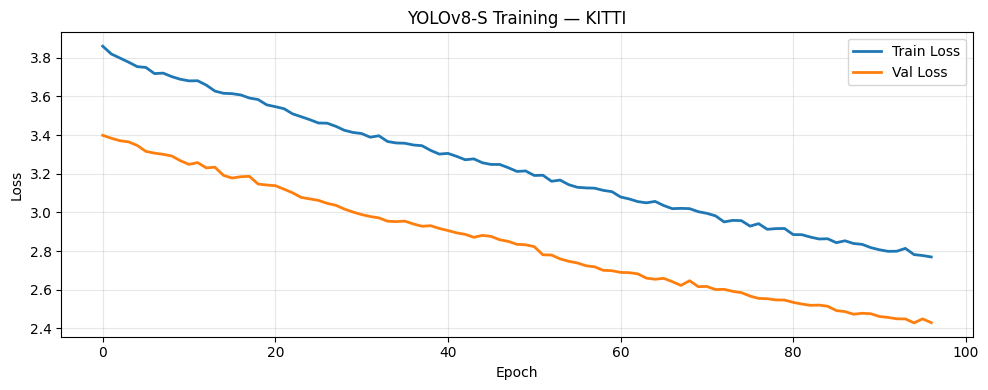

Loss curve saved to weights/loss_curve.png


In [9]:
plt.figure(figsize=(10, 4))
plt.plot(history['train'], label='Train Loss', linewidth=2)
plt.plot(history['val'],   label='Val Loss',   linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title(f'YOLOv8-{VERSION.upper()} Training — KITTI')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(WEIGHTS_DIR / 'loss_curve.png', dpi=150)
plt.show()
print('Loss curve saved to weights/loss_curve.png')